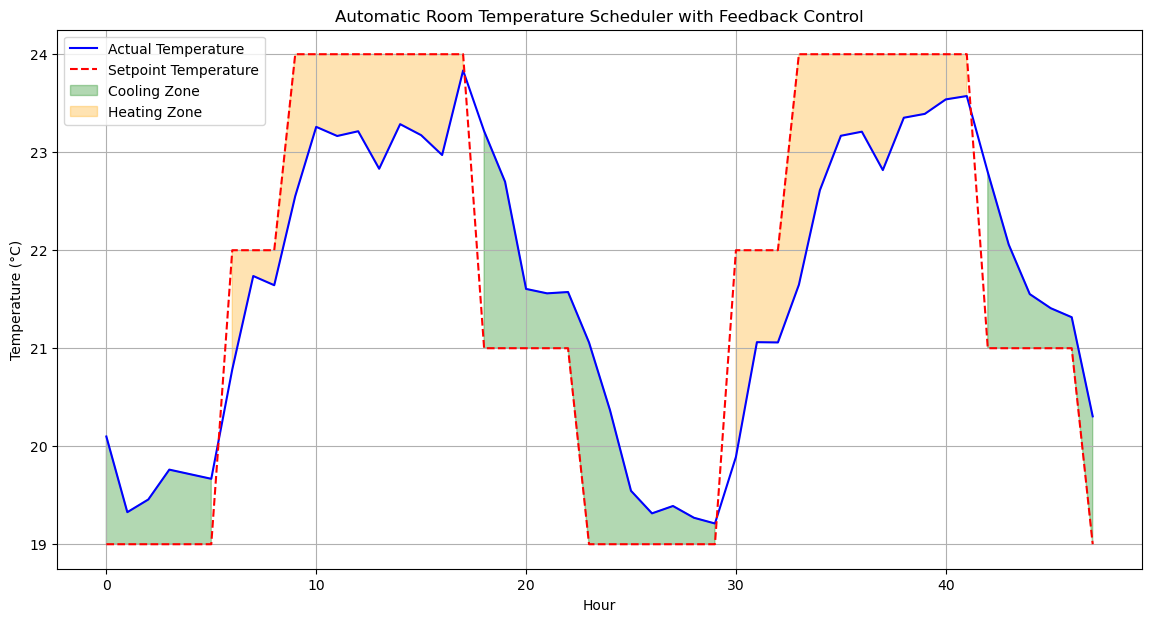

,Hour,Actual Temperature,Setpoint Temperature,Action
0,0,20.099343,19,Idle
1,1,19.326996,19,Cooling
2,2,19.456533,19,Idle
3,3,19.761139,19,Idle
4,4,19.714309,19,Idle


In [2]:
# --- Import necessary libraries ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Define the schedule ---
def get_setpoint(current_hour):
    if 6 <= current_hour < 9:
        return 22  # Morning
    elif 9 <= current_hour < 18:
        return 24  # Work hours
    elif 18 <= current_hour < 23:
        return 21  # Evening
    else:
        return 19  # Night

# --- Step 2: Simulate the environment ---
np.random.seed(42)  # For consistent results
hours = np.arange(0, 48)  # Simulate for 2 days (48 hours)

actual_temperature = []
setpoint_temperature = []
actions = []

current_temp = 20  # Starting room temperature

for hour in hours:
    # Determine the desired temperature from the schedule
    setpoint = get_setpoint(hour % 24)  # %24 because the day restarts after 24h
    
    # Feedback control logic
    error = setpoint - current_temp
    if error > 1:
        action = "Heating"
        current_temp += 0.8 + np.random.normal(0, 0.2)  # Add heater effect + randomness
    elif error < -1:
        action = "Cooling"
        current_temp -= 0.8 + np.random.normal(0, 0.2)  # Add cooler effect + randomness
    else:
        action = "Idle"
        current_temp += np.random.normal(0, 0.2)  # Small random fluctuation when idle
    
    # Record data
    actual_temperature.append(current_temp)
    setpoint_temperature.append(setpoint)
    actions.append(action)

# --- Step 3: Create a DataFrame for results ---
df = pd.DataFrame({
    'Hour': hours,
    'Actual Temperature': actual_temperature,
    'Setpoint Temperature': setpoint_temperature,
    'Action': actions
})

# --- Step 4: Plot the results ---
plt.figure(figsize=(14,7))
plt.plot(df['Hour'], df['Actual Temperature'], label='Actual Temperature', color='blue')
plt.plot(df['Hour'], df['Setpoint Temperature'], label='Setpoint Temperature', color='red', linestyle='--')
plt.fill_between(df['Hour'], df['Setpoint Temperature'], df['Actual Temperature'],
                 where=(df['Actual Temperature'] > df['Setpoint Temperature']),
                 color='green', alpha=0.3, label='Cooling Zone')
plt.fill_between(df['Hour'], df['Setpoint Temperature'], df['Actual Temperature'],
                 where=(df['Actual Temperature'] < df['Setpoint Temperature']),
                 color='orange', alpha=0.3, label='Heating Zone')

plt.title('Automatic Room Temperature Scheduler with Feedback Control')
plt.xlabel('Hour')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# --- Step 5: Show the first few rows of the simulation data ---
df.head()
